In [1]:
import pandas as pd

network_data= pd.read_csv("/content/LevenMelvilleRelationalTables - MelvilleHamiltonCombined.csv")
network_data.head()

,From Type,From Name,Edge Type,To Type,To Name,Weight
0,Person,King William,Approbation,Person,Melville,1
1,Person,King William,Exoneration,Person,Tarbat,1
2,Person,King William,Instructions,Person,Melville,7
3,Person,King William,Instructions,Organization,Convention of Estates,1
4,Person,King William,Instructions,Group,Leven & Mackay,1


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [4]:
print("First 5 rows of network_data:")
print(network_data.head())

print("\nInformation about network_data DataFrame:")
network_data.info()

print("\nDescriptive statistics for network_data:")
print(network_data.describe())

First 5 rows of network_data:
  From Type     From Name     Edge Type       To Type                To Name  \
0    Person  King William   Approbation        Person               Melville   
1    Person  King William   Exoneration        Person                 Tarbat   
2    Person  King William  Instructions        Person               Melville   
3    Person  King William  Instructions  Organization  Convention of Estates   
4    Person  King William  Instructions         Group         Leven & Mackay   

   Weight  
0       1  
1       1  
2       7  
3       1  
4       1  

Information about network_data DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   From Type  469 non-null    object
 1   From Name  469 non-null    object
 2   Edge Type  469 non-null    object
 3   To Type    469 non-null    object
 4   To Name    469 non-null    obje

In [6]:
print("\nNumber of unique values for categorical columns:")
print(f"Unique values in 'From Type': {network_data['From Type'].nunique()}")
print(f"Unique values in 'To Type': {network_data['To Type'].nunique()}")
print(f"Unique values in 'Edge Type': {network_data['Edge Type'].nunique()}")
print(f"Unique values in 'From Name': {network_data['From Name'].nunique()}")
print(f"Unique values in 'To Name': {network_data['To Name'].nunique()}")


Number of unique values for categorical columns:
Unique values in 'From Type': 5
Unique values in 'To Type': 5
Unique values in 'Edge Type': 53
Unique values in 'From Name': 265
Unique values in 'To Name': 146


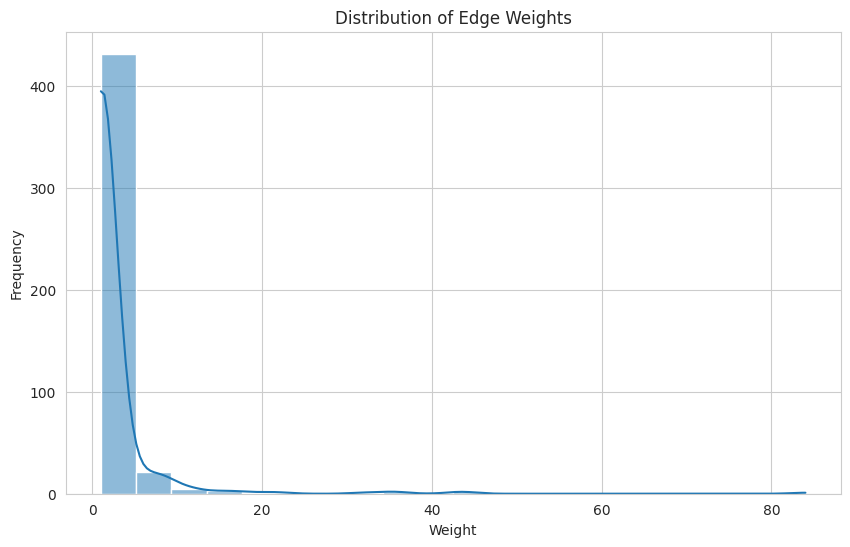

In [8]:
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(network_data['Weight'], bins=20, kde=True)
plt.title('Distribution of Edge Weights')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-1758459003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=network_data, x=col, order=network_data[col].value_counts().index, palette='viridis')


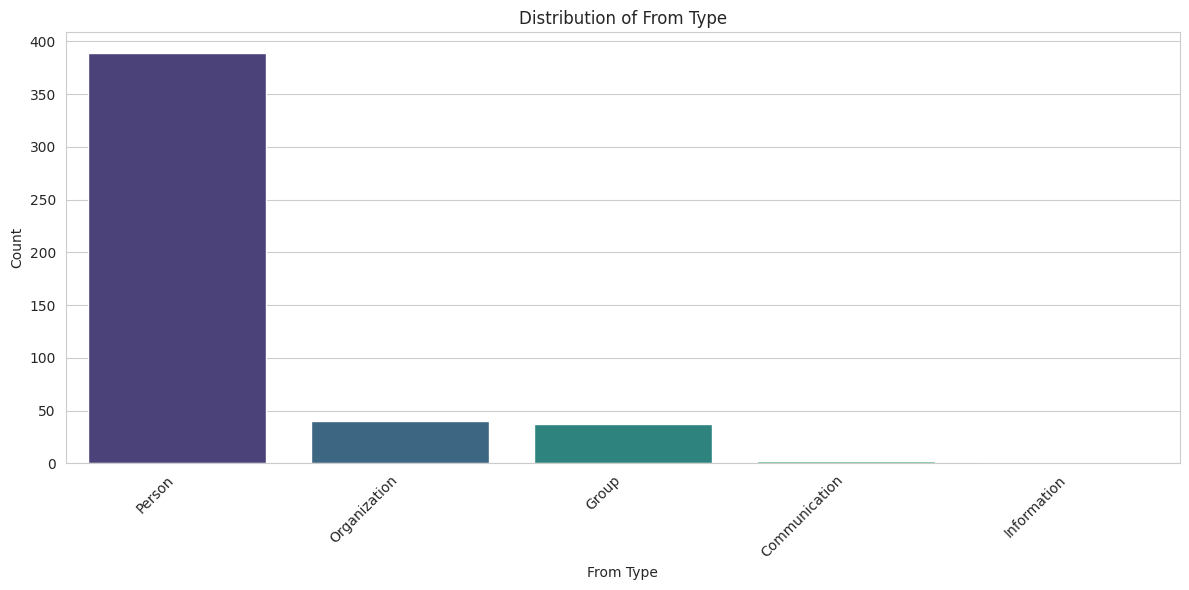

/tmp/ipython-input-1758459003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=network_data, x=col, order=network_data[col].value_counts().index, palette='viridis')


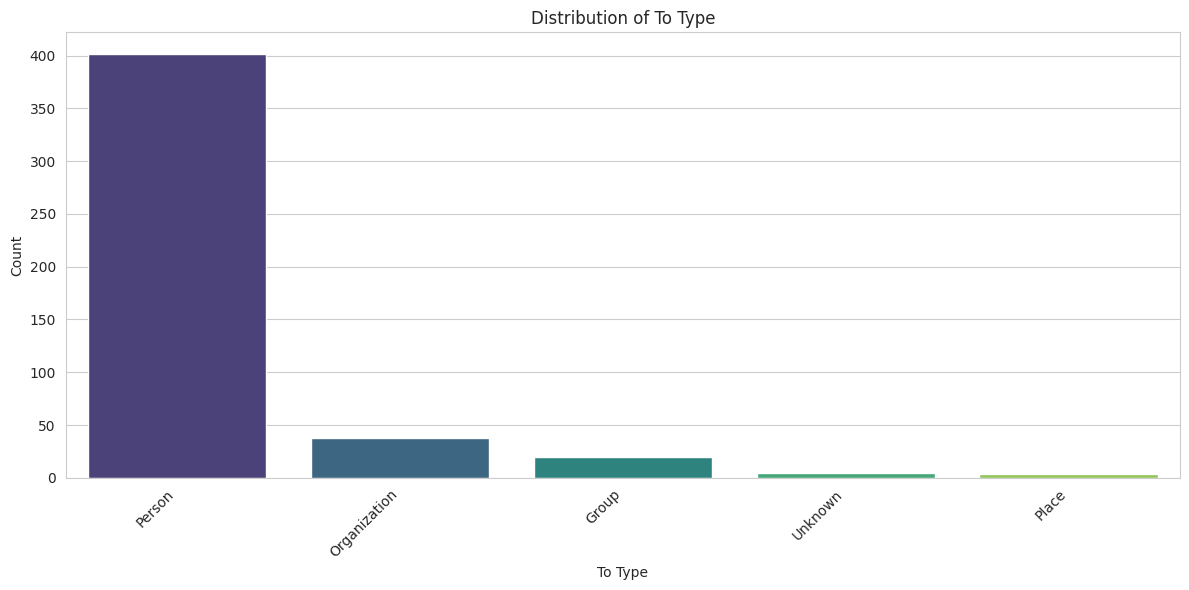

/tmp/ipython-input-1758459003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=network_data, x=col, order=network_data[col].value_counts().index, palette='viridis')


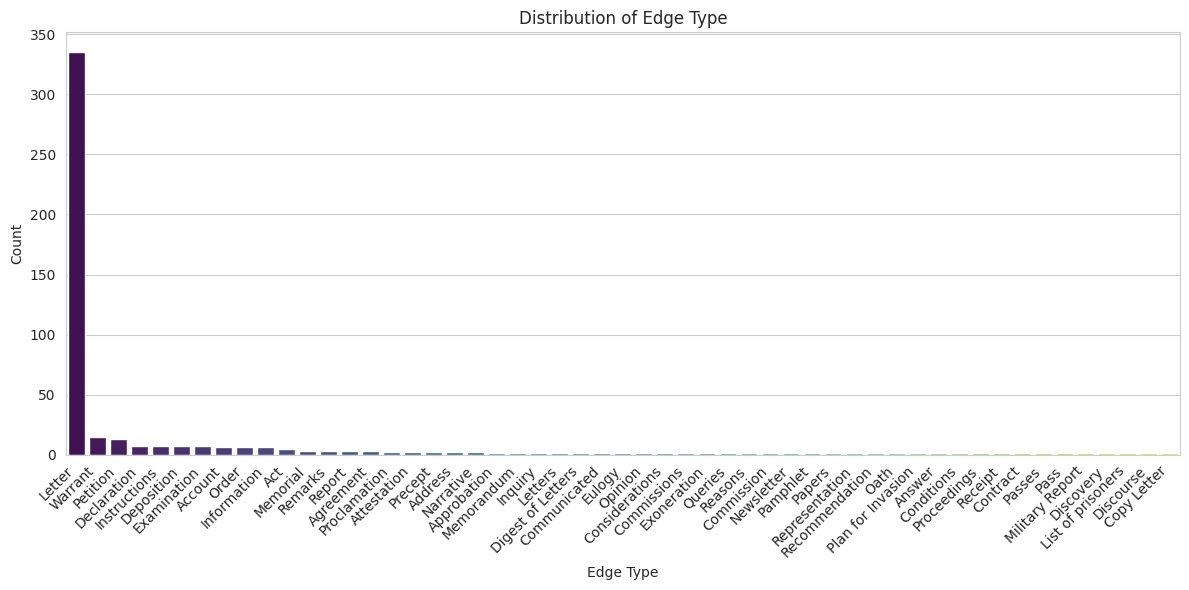

In [10]:
categorical_columns = ['From Type', 'To Type', 'Edge Type']

for col in categorical_columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=network_data, x=col, order=network_data[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

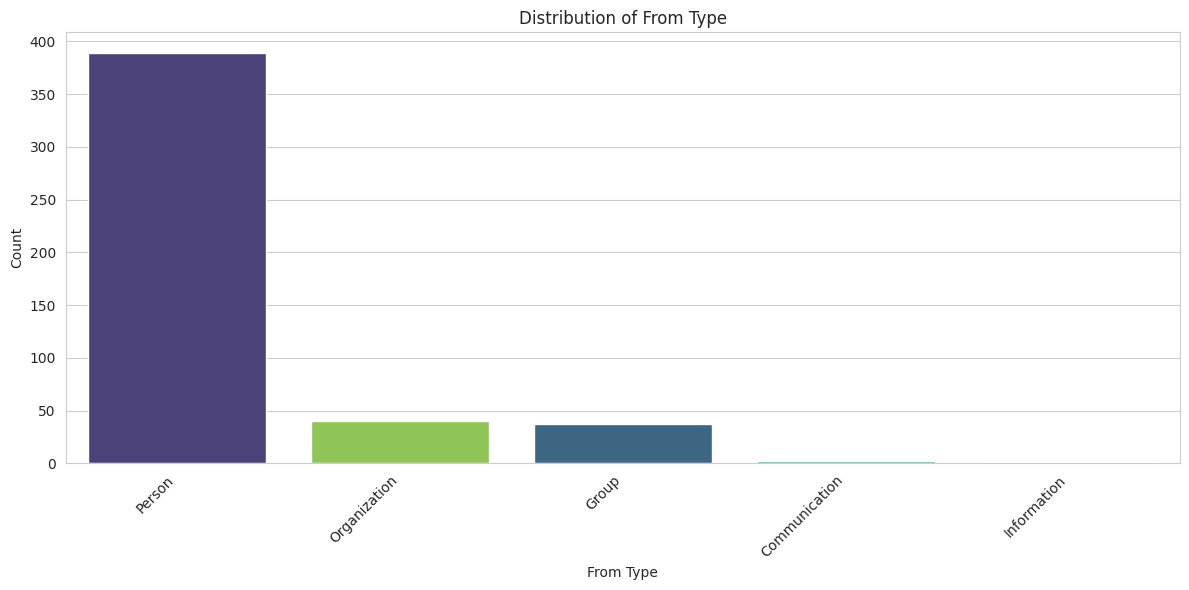

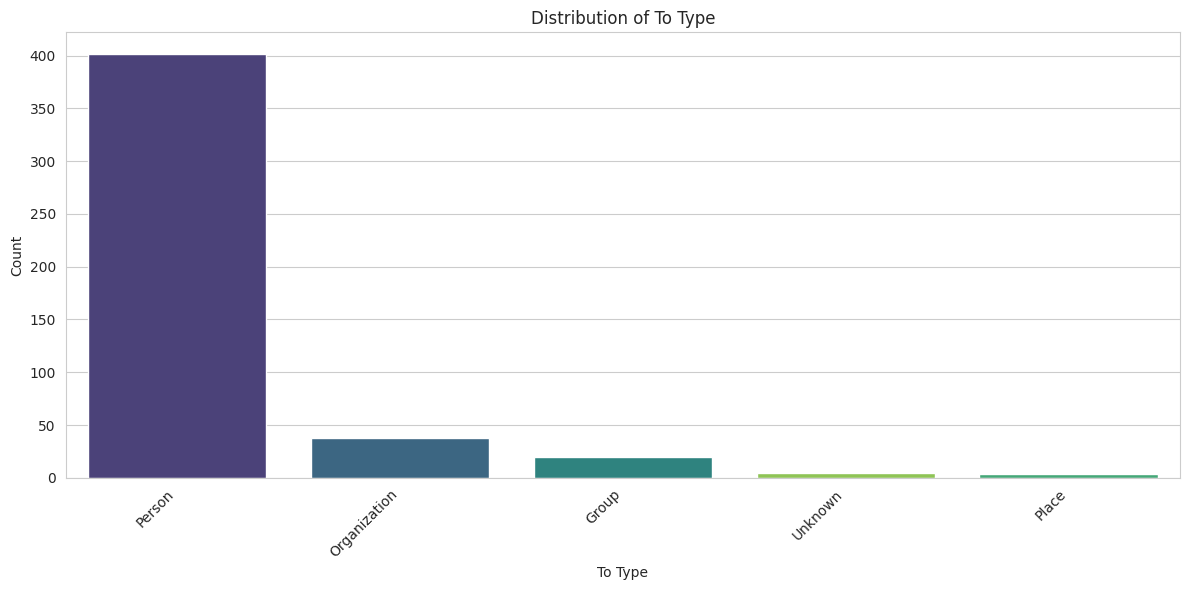

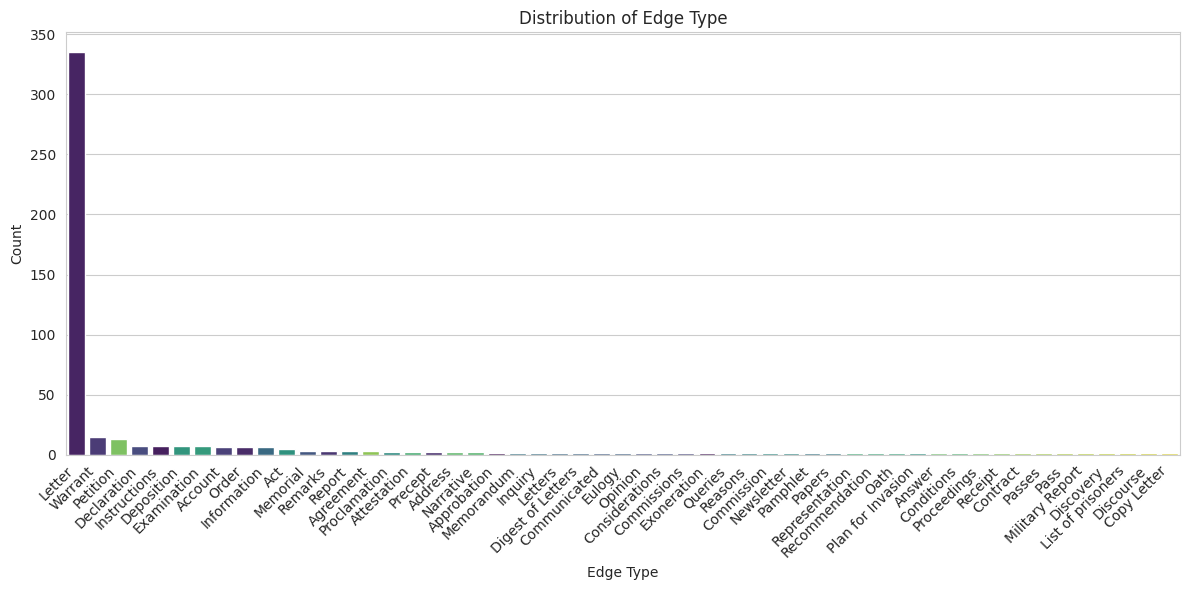

In [12]:
categorical_columns = ['From Type', 'To Type', 'Edge Type']

for col in categorical_columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=network_data, x=col, order=network_data[col].value_counts().index, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [14]:
G = nx.DiGraph()
print("Empty directed graph initialized.")

Empty directed graph initialized.


Graph created with 365 nodes and 423 edges.


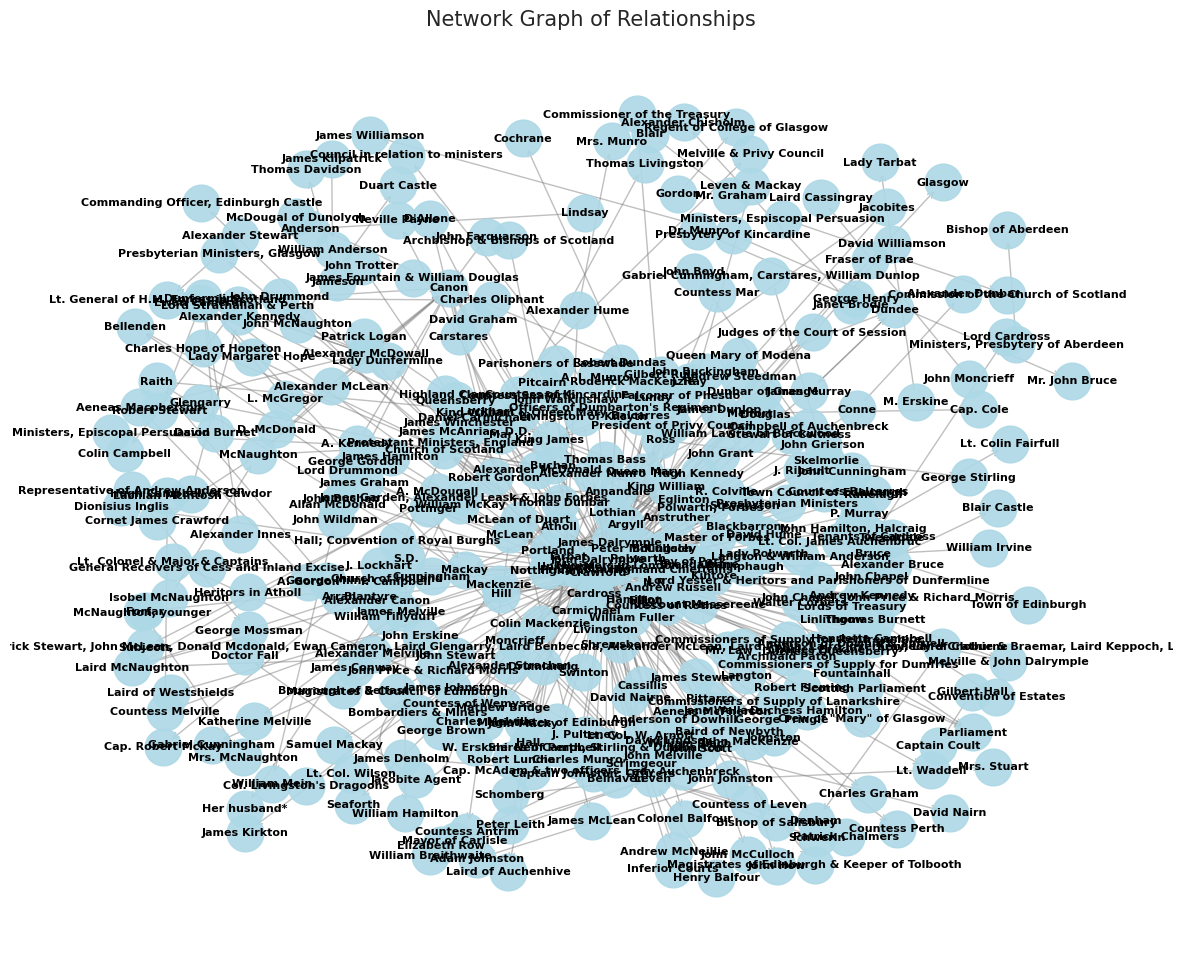

In [16]:
for index, row in network_data.iterrows():
    G.add_edge(row['From Name'], row['To Name'], edge_type=row['Edge Type'], weight=row['Weight'])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Calculate layout positions for the nodes
pos = nx.spring_layout(G, k=0.15, iterations=20)

plt.figure(figsize=(15, 12))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue', alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, arrowstyle='->', arrowsize=10)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title('Network Graph of Relationships', size=15)
plt.axis('off')
plt.show()

In [17]:
import pandas as pd

network_data= pd.read_csv("/content/LevenMelvilleRelationalTables - Combined-data-simple.csv")
network_data.head()

,Source,Target,Weight
0,King William,Melville,1
1,King William,Tarbat,1
2,King William,Melville,7
3,King William,Convention of Estates,1
4,King William,Leven & Mackay,1


In [19]:
print("First 5 rows of network_data:")
print(network_data.head())

print("\nInformation about network_data DataFrame:")
network_data.info()

print("\nDescriptive statistics for network_data:")
print(network_data.describe())

First 5 rows of network_data:
         Source                 Target  Weight
0  King William               Melville       1
1  King William                 Tarbat       1
2  King William               Melville       7
3  King William  Convention of Estates       1
4  King William         Leven & Mackay       1

Information about network_data DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Source  469 non-null    object
 1   Target  469 non-null    object
 2   Weight  469 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 11.1+ KB

Descriptive statistics for network_data:
           Weight
count  469.000000
mean     2.381663
std      5.869791
min      1.000000
25%      1.000000
50%      1.000000
75%      1.000000
max     84.000000


Empty directed graph G_new initialized.
Graph G_new created with 365 nodes and 423 edges.


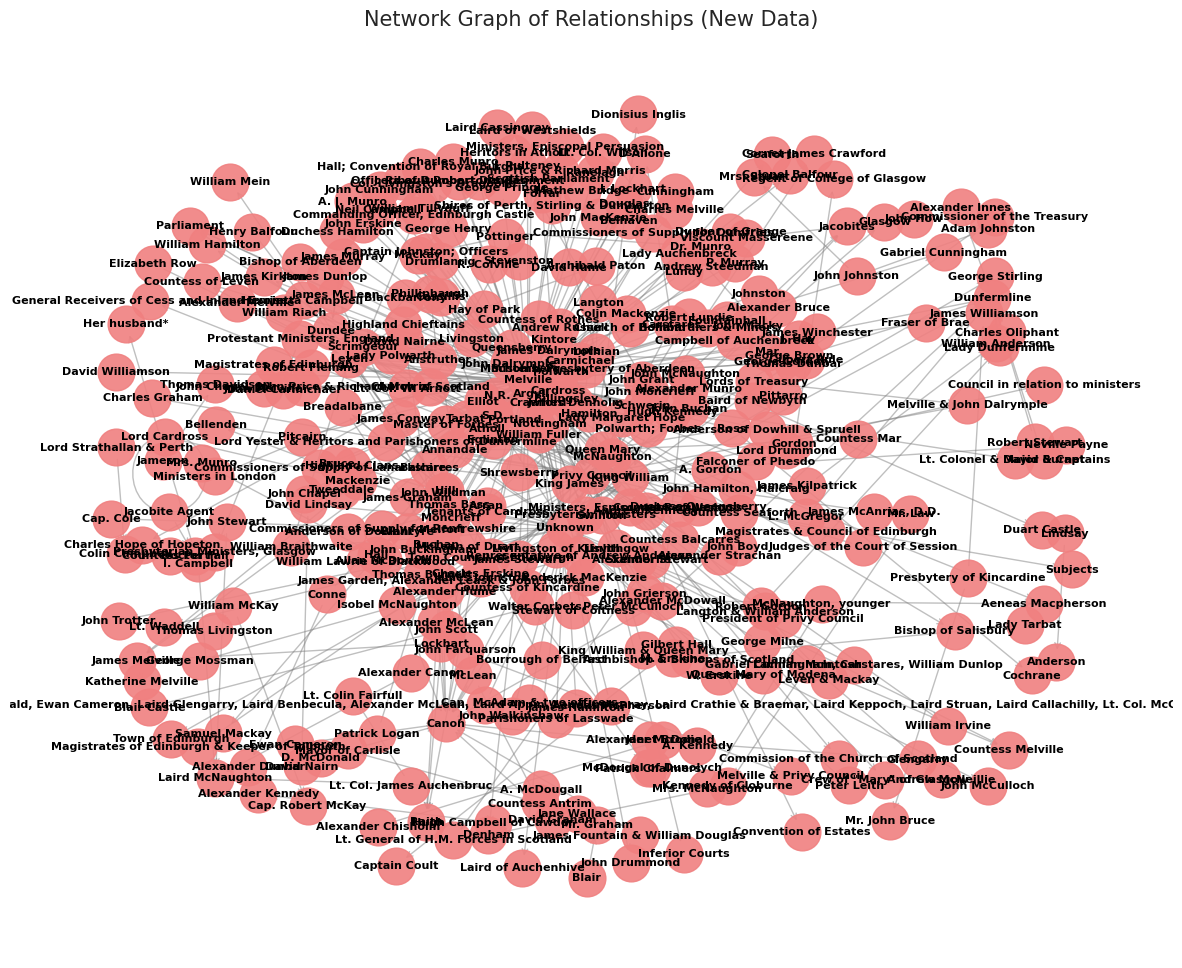

In [20]:
G_new = nx.DiGraph()
print("Empty directed graph G_new initialized.")

for index, row in network_data.iterrows():
    G_new.add_edge(row['Source'], row['Target'], weight=row['Weight'])

print(f"Graph G_new created with {G_new.number_of_nodes()} nodes and {G_new.number_of_edges()} edges.")

# Calculate layout positions for the nodes
pos_new = nx.spring_layout(G_new, k=0.15, iterations=20)

plt.figure(figsize=(15, 12))

# Draw nodes
nx.draw_networkx_nodes(G_new, pos_new, node_size=700, node_color='lightcoral', alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G_new, pos_new, edge_color='gray', alpha=0.5, arrowstyle='->', arrowsize=10)

# Draw labels
nx.draw_networkx_labels(G_new, pos_new, font_size=8, font_weight='bold')

plt.title('Network Graph of Relationships (New Data)', size=15)
plt.axis('off')
plt.show()

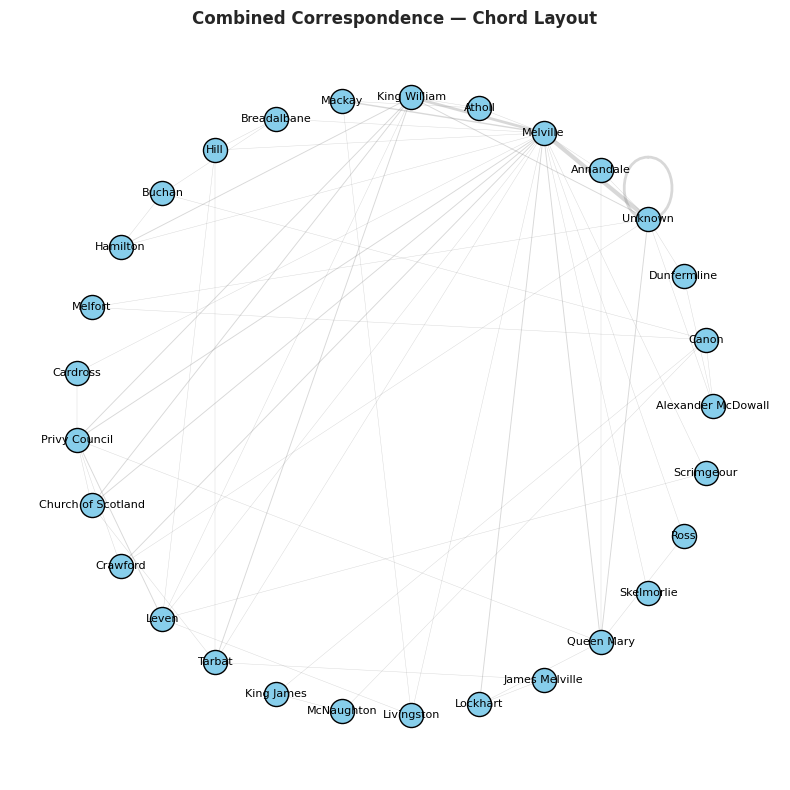

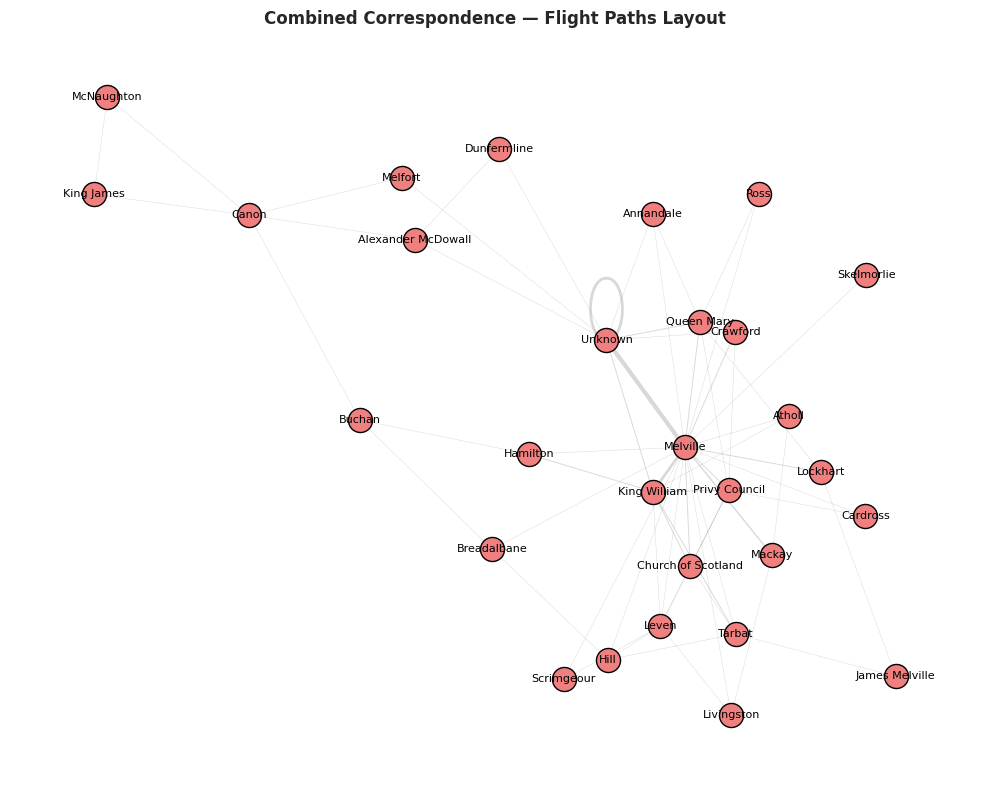

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

sender_col = 'Source'
receiver_col = 'Target'

edge_counts = (
    network_data.groupby([sender_col, receiver_col])
    .size()
    .reset_index(name='count'))
top_n = 30
top_nodes = pd.concat([
    edge_counts[sender_col],
    edge_counts[receiver_col]
]).value_counts().head(top_n).index

edge_counts = edge_counts[
    edge_counts[sender_col].isin(top_nodes) &
    edge_counts[receiver_col].isin(top_nodes)]

G = nx.Graph()
for _, row in edge_counts.iterrows():
    G.add_edge(row[sender_col], row[receiver_col], weight=row['count'])

pos_circle = nx.circular_layout(G)

pos_spring = nx.spring_layout(G, seed=42, k=0.4)

plt.figure(figsize=(8, 8))
edges = nx.draw_networkx_edges(G, pos_circle, alpha=0.3, width=[d['weight']/3 for _, _, d in G.edges(data=True)], edge_color='gray')
nodes = nx.draw_networkx_nodes(G, pos_circle, node_size=300, node_color='skyblue', edgecolors='black')
labels = nx.draw_networkx_labels(G, pos_circle, font_size=8)
plt.axis('off')
plt.title('Combined Correspondence — Chord Layout', fontweight='bold')
plt.tight_layout()
plt.savefig("combined_chord.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 8))
edges = nx.draw_networkx_edges(G, pos_spring, alpha=0.3, width=[d['weight']/3 for _, _, d in G.edges(data=True)], edge_color='gray')
nodes = nx.draw_networkx_nodes(G, pos_spring, node_size=300, node_color='lightcoral', edgecolors='black')
labels = nx.draw_networkx_labels(G, pos_spring, font_size=8)
plt.axis('off')
plt.title('Combined Correspondence — Flight Paths Layout', fontweight='bold')
plt.tight_layout()
plt.savefig("combined_flightpaths.png", dpi=300)
plt.show()